## Overview

`Model3` implements the nonlinear threshold model of glacial cycles from Ganopolski (2024). It tracks normalised ice volume `v` and a discrete glacial regime `k` (1 = glaciation, 2 = deglaciation). Orbital forcing `f(t)` drives transitions between regimes.

### Equations

**Glaciation phase** (k = 1): ice volume relaxes toward a forcing-dependent equilibrium
$$\frac{dv}{dt} = \frac{v_e(f) - v}{\tau_1}$$

**Deglaciation phase** (k = 2): rapid, constant-rate collapse
$$\frac{dv}{dt} = -\frac{v_c}{\tau_2}$$

### Regime switches

| Transition | Condition |
|---|---|
| k=1 → k=2 (termination onset) | v > v_c  **and**  df/dt > 0  **and**  f > 0 |
| k=2 → k=1 (glaciation onset) | f < f_1 |

### Parameters

| Name | Description | Default |
|---|---|---|
| `f1` | Insolation threshold for glaciation onset (W m⁻²) | −16 |
| `f2` | Upper insolation threshold (W m⁻²) | 16 |
| `t1` | Glaciation relaxation timescale (kyr) | 30 |
| `t2` | Deglaciation timescale (kyr) | 10 |
| `vc` | Critical ice volume for termination trigger | 1.4 |

All parameters accept a `float`, callable `(t)` / `(t, state)`, or `cc.Forcing`.

State variables: `v` (normalised ice volume), `k` (regime index, non-integrated).  
Diagnostic: `insolation` — the applied orbital forcing value f(t) at each output step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.g24 import Model3, calc_f, vc_func

## Basic run

In [2]:
# Instantiate with default parameters (f1=-16, f2=16, t1=30, t2=10, vc=1.4)
model = Model3()

# Orbital forcing must be registered — it is time-varying, not a static scalar
model.register_forcing('insolation', cc.Forcing(calc_f))

# max_step=0.5 kyr is critical: regime switches (k=1↔2) are discrete events
# inside dydt. An adaptive solver with large steps can stride over a switch
# condition, missing terminations entirely.
output = model.integrate(t_span=(-2000, 0), y0=[0.0, 1], method='RK45',
                         kwargs={'max_step': 0.5})

/Users/jlanders/PycharmProjects/ClimateCritters/climatecritters/model_critters/g24.py:213: RuntimeWarning: invalid value encountered in sqrt
  return 1 + np.sqrt((f2 - f) / (f2 - f1))
/Users/jlanders/PycharmProjects/ClimateCritters/climatecritters/model_critters/g24.py:232: RuntimeWarning: invalid value encountered in sqrt
  return 1 - np.sqrt((f2 - f) / (f2 - f1))


Terminations in 2000 kyr: 14  (mean cycle ~143 kyr)
Max ice volume: 1.74


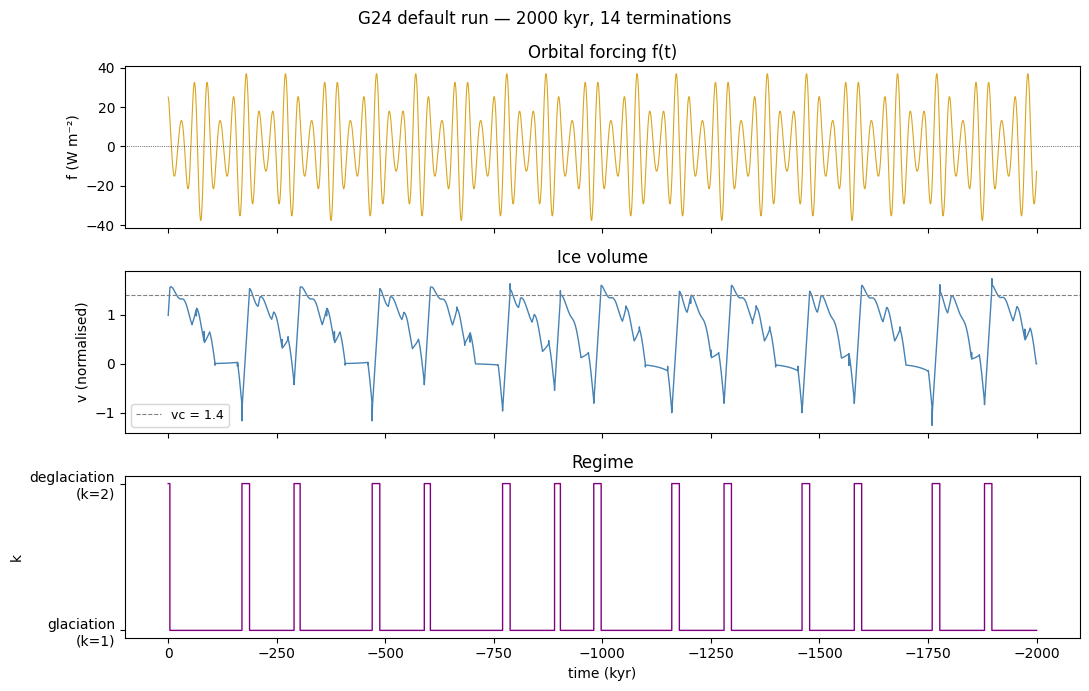

In [3]:
v          = output.state_variables['v']
k          = output.state_variables['k']
insolation = output.diagnostic_variables['insolation']
time       = output.time

# Count terminations (1→2 transitions in k)
n_term = int(np.sum(np.diff(k) > 0))
print(f"Terminations in 2000 kyr: {n_term}  (mean cycle ~{2000 / n_term:.0f} kyr)")
print(f"Max ice volume: {v.max():.2f}")

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

# Insolation forcing — drives regime switches
axes[0].plot(time, insolation, color='goldenrod', lw=0.8)
axes[0].axhline(0, color='k', lw=0.5, ls=':')
axes[0].set_ylabel('f (W m\u207b\u00b2)'); axes[0].set_title('Orbital forcing f(t)')

# Ice volume — sawtooth: slow glaciation, rapid termination
axes[1].plot(time, v, color='steelblue', lw=1)
axes[1].axhline(model.vc, color='gray', ls='--', lw=0.8, label=f'vc = {model.vc}')
axes[1].set_ylabel('v (normalised)'); axes[1].set_title('Ice volume')
axes[1].legend(fontsize=9)

# Regime: 1 = glaciation (building), 2 = deglaciation (termination)
axes[2].step(time, k, color='purple', lw=1, where='post')
axes[2].set_yticks([1, 2])
axes[2].set_yticklabels(['glaciation\n(k=1)', 'deglaciation\n(k=2)'])
axes[2].set_ylabel('k'); axes[2].set_xlabel('time (kyr)')
axes[2].set_title('Regime')

fig.suptitle(f'G24 default run — 2000 kyr, {n_term} terminations')
for ax in axes:
    ax.invert_xaxis()   # geological convention: older on right
plt.tight_layout(); plt.show()

**Figure.** Top: orbital forcing $f(t)$ — the signal that drives regime switches. Middle: normalised ice volume $v$; rises during glaciation, drops sharply at each termination. Bottom: regime state $k$ (1 = glaciation, 2 = deglaciation). Terminations align with insolation maxima that exceed the deglaciation threshold $f_2$; the model reproduces ~100 kyr cycles over the last 800 kyr.

## Orbital forcing

`calc_f` provides the Ganopolski (2024) orbital forcing — a precession signal with eccentricity-modulated amplitude:

$$f(t) = A \bigl(1 + \varepsilon\,\sin(2\pi t / T_1)\bigr)\cos(2\pi t / T_2)$$

The $T_2 = 30$ kyr precession carrier is amplitude-modulated at $T_1 = 100$ kyr (eccentricity). The result has pronounced 100 kyr amplitude beats — maximal precession peaks during eccentricity maxima.

Register the forcing as a `Forcing` object so it is evaluated at every solver step:

```python
model.register_forcing('insolation', cc.Forcing(calc_f))
```


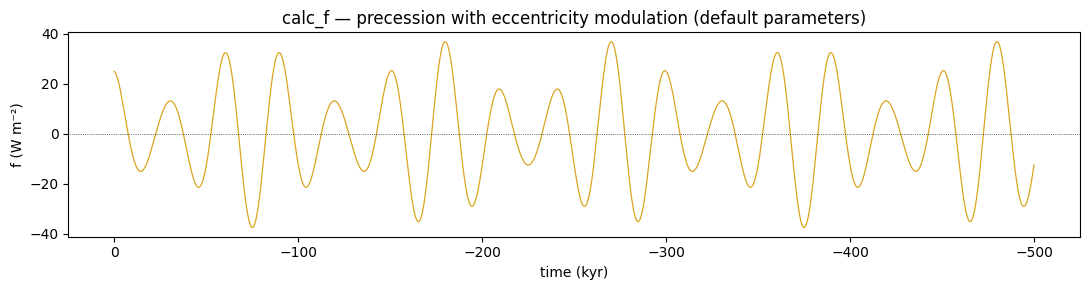

In [4]:
# Plot the forcing signal over the last 500 kyr to resolve both precession and eccentricity
t_range = np.linspace(-500, 0, 5000)
f_vals  = calc_f(t_range)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_range, f_vals, color='goldenrod', lw=0.9)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('time (kyr)'); ax.set_ylabel('f (W m\u207b\u00b2)')
ax.set_title('calc_f — precession with eccentricity modulation (default parameters)')
ax.invert_xaxis()
plt.tight_layout(); plt.show()

**Figure.** The `calc_f` forcing over the last 500 kyr. The signal is dominated by the ~23 kyr precession cycle, with amplitude modulated at ~100 kyr by eccentricity — the beat between consecutive precession cycles is clearly visible near 400 kyr BP.

### Forcing parameters

| Parameter | Description | Default |
|---|---|---|
| `A` | Amplitude (W m⁻²) | 25 |
| `eps` | Eccentricity modulation depth | 0.5 |
| `T1` | Eccentricity period (kyr) | 100 |
| `T2` | Precession period (kyr) | 30 |

`eps=0` removes the eccentricity envelope, leaving constant-amplitude precession. Comparing the two forcing signals makes the 100 kyr amplitude modulation explicit:


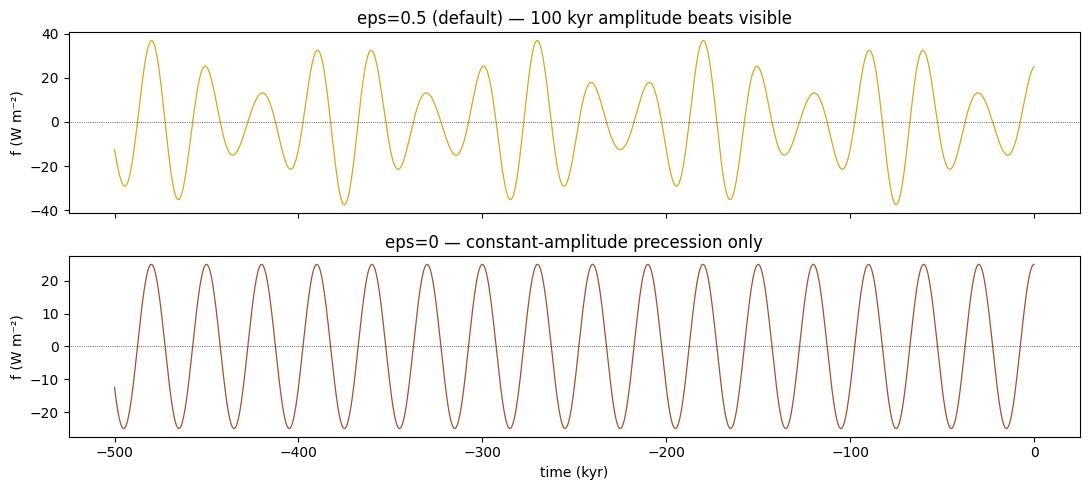

In [5]:
f_eps05 = calc_f(t_range, eps=0.5)   # default: eccentricity modulation on
f_eps0  = calc_f(t_range, eps=0)     # pure precession, constant amplitude

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t_range, f_eps05, color='goldenrod', lw=0.9)
axes[0].set_ylabel('f (W m\u207b\u00b2)')
axes[0].set_title('eps=0.5 (default) — 100 kyr amplitude beats visible')

axes[1].plot(t_range, f_eps0, color='sienna', lw=0.9)
axes[1].set_ylabel('f (W m\u207b\u00b2)')
axes[1].set_title('eps=0 — constant-amplitude precession only')

for ax in axes:
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.invert_xaxis()
axes[1].set_xlabel('time (kyr)')
plt.tight_layout(); plt.show()

**Figure.** Top (`eps=0.5`): eccentricity modulation is on — amplitude waxes and wanes on the 100 kyr eccentricity cycle, producing large and small precession maxima alternately. Bottom (`eps=0`): pure precession at fixed amplitude. Eccentricity modulation is what intermittently 'unlocks' large terminations in the model.

## Ice volume threshold: vc

`vc` is the minimum ice volume required to trigger a termination (k=1 → k=2). It controls both the dominant cycle period and the sawtooth asymmetry:

- **Low `vc`** (≈ 0.65): deglaciation triggers after modest ice build-up → frequent terminations → shorter cycles
- **High `vc`** (≈ 1.4): substantial ice build-up required → the system skips forcing beats until enough ice accumulates → longer cycles

The default `vc=1.4` reproduces the late Pleistocene 100-kyr world. Note that the `calc_f` forcing is purely precession-based (no obliquity), so minimum cycle lengths are set by the glaciation timescale `t1`, not the 41-kyr obliquity period.


In [6]:
# Compare three vc values
vc_values = [0.65, 1.0, 1.4]
vc_colors = ['steelblue', 'seagreen', 'firebrick']
vc_runs   = []

for vc_val in vc_values:
    m = Model3(vc=vc_val)
    m.register_forcing('insolation', cc.Forcing(calc_f))
    out = m.integrate(t_span=(-2000, 0), y0=[0.0, 1], method='RK45',
                      kwargs={'max_step': 0.5})
    vc_runs.append((vc_val, out))

for vc_val, out in vc_runs:
    k_out  = out.state_variables['k']
    n_t    = int(np.sum(np.diff(k_out) > 0))
    print(f"vc={vc_val:.2f}: {n_t} terminations  "
          f"(mean cycle ~{2000 / n_t:.0f} kyr)")

/Users/jlanders/PycharmProjects/ClimateCritters/climatecritters/model_critters/g24.py:213: RuntimeWarning: invalid value encountered in sqrt
  return 1 + np.sqrt((f2 - f) / (f2 - f1))
/Users/jlanders/PycharmProjects/ClimateCritters/climatecritters/model_critters/g24.py:232: RuntimeWarning: invalid value encountered in sqrt
  return 1 - np.sqrt((f2 - f) / (f2 - f1))


vc=0.65: 28 terminations  (mean cycle ~71 kyr)
vc=1.00: 18 terminations  (mean cycle ~111 kyr)
vc=1.40: 14 terminations  (mean cycle ~143 kyr)


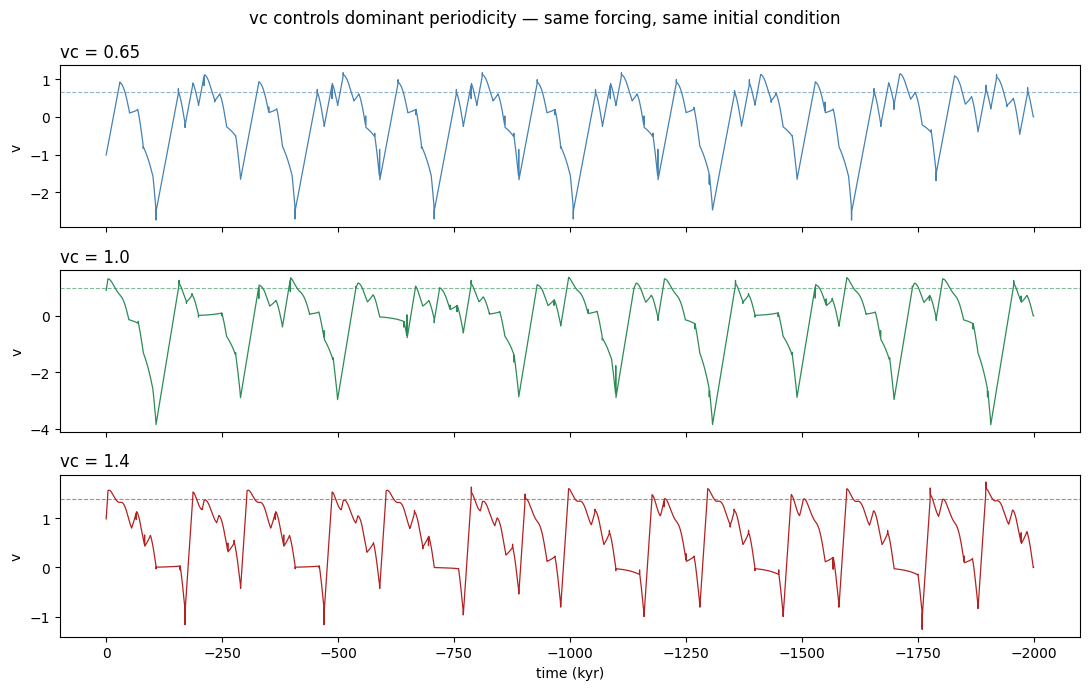

In [7]:
fig, axes = plt.subplots(len(vc_values), 1, figsize=(11, 7), sharex=True)

for ax, (vc_val, out), color in zip(axes, vc_runs, vc_colors):
    v_out = out.state_variables['v']
    ax.plot(out.time, v_out, color=color, lw=0.9)
    # Dashed line shows the vc threshold each run must cross to deglaciate
    ax.axhline(vc_val, color=color, ls='--', lw=0.8, alpha=0.6)
    ax.set_ylabel('v')
    ax.set_title(f'vc = {vc_val}', loc='left')
    ax.invert_xaxis()

axes[-1].set_xlabel('time (kyr)')
fig.suptitle('vc controls dominant periodicity — same forcing, same initial condition')
plt.tight_layout(); plt.show()

**Figure.** Ice volume $v(t)$ for three values of $v_c$. Low $v_c=0.65$: terminations trigger readily — short, ~40 kyr obliquity-paced cycles. Middle $v_c=1.0$: some precession cycles are 'skipped', yielding irregular 80–100 kyr cycles. High $v_c=1.4$ (default): only the largest insolation maxima can drive a termination, producing canonical 100 kyr glacial cycles with saw-tooth asymmetry.

## Mid-Pleistocene Transition

The Mid-Pleistocene Transition (MPT, ~1.2–0.8 Ma) saw glacial cycles lengthen from ~40 kyr to ~100 kyr with no corresponding change in orbital forcing. In this model the MPT is reproduced by a gradual increase in `vc`, captured by `vc_func` — a sigmoid ramp between a pre-MPT and post-MPT value:

$$v_c(t) = \frac{v_{c1} + v_{c2}}{2} + \frac{v_{c2} - v_{c1}}{2}\,\tanh\!\left(\frac{t - t_{\mathrm{MPT}}}{\tau_1}\right)$$

Default: `vc1=0.65` (pre-MPT), `vc2=1.38` (post-MPT), `t_MPT=−1050 kyr`, `τ₁=250 kyr`.

`vc_func` has keyword arguments beyond `t`, so it must be wrapped in a lambda before passing as a parameter callable — the dispatcher only accepts signatures `(t)`, `(t, state)`, or `(t, state, model)`:

```python
Model3(vc=lambda t: vc_func(t))
```


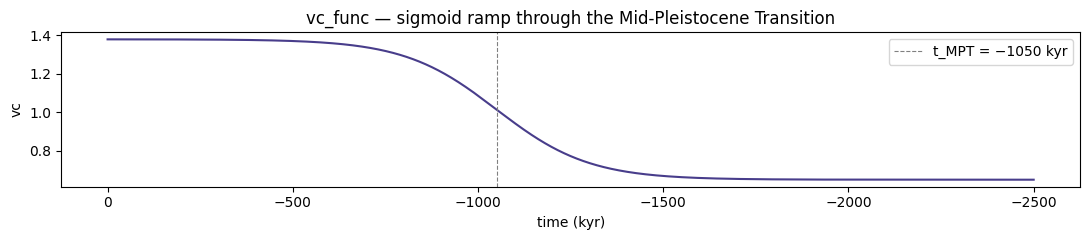

In [8]:
# Plot vc_func over the full integration span
t_long  = np.linspace(-2500, 0, 5000)
vc_vals = vc_func(t_long)

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(t_long, vc_vals, color='darkslateblue', lw=1.5)
ax.axvline(-1050, color='gray', ls='--', lw=0.8, label='t_MPT = \u22121050 kyr')
ax.set_xlabel('time (kyr)'); ax.set_ylabel('vc')
ax.set_title('vc_func — sigmoid ramp through the Mid-Pleistocene Transition')
ax.invert_xaxis(); ax.legend()
plt.tight_layout(); plt.show()

**Figure.** The sigmoid $v_c(t)$ ramp used to model the MPT. Before ~1.2 Ma $v_c$ is low (obliquity world), after ~0.8 Ma it is high (eccentricity world); the transition is smoothed over ~400 kyr.

In [9]:
# vc_func has keyword args (vc1, vc2, ...) beyond t, so wrap it in a lambda.
# The parameter dispatcher only accepts (t), (t, state), or (t, state, model).
model_mpt = Model3(vc=lambda t: vc_func(t))
model_mpt.register_forcing('insolation', cc.Forcing(calc_f))
out_mpt = model_mpt.integrate(t_span=(-2500, 0), y0=[0.0, 1], method='RK45',
                               kwargs={'max_step': 0.5})

v_mpt    = out_mpt.state_variables['v']
k_mpt    = out_mpt.state_variables['k']
time_mpt = out_mpt.time

# Count terminations before and after the MPT centre
pre  = time_mpt < -1050
post = time_mpt > -1050
n_pre  = int(np.sum(np.diff(k_mpt[pre])  > 0))
n_post = int(np.sum(np.diff(k_mpt[post]) > 0))
print(f"Pre-MPT  terminations: {n_pre}   (~{1450 / max(n_pre, 1):.0f} kyr mean cycle)")
print(f"Post-MPT terminations: {n_post}  (~{1050 / max(n_post, 1):.0f} kyr mean cycle)")

Pre-MPT  terminations: 23   (~63 kyr mean cycle)
Post-MPT terminations: 8  (~131 kyr mean cycle)


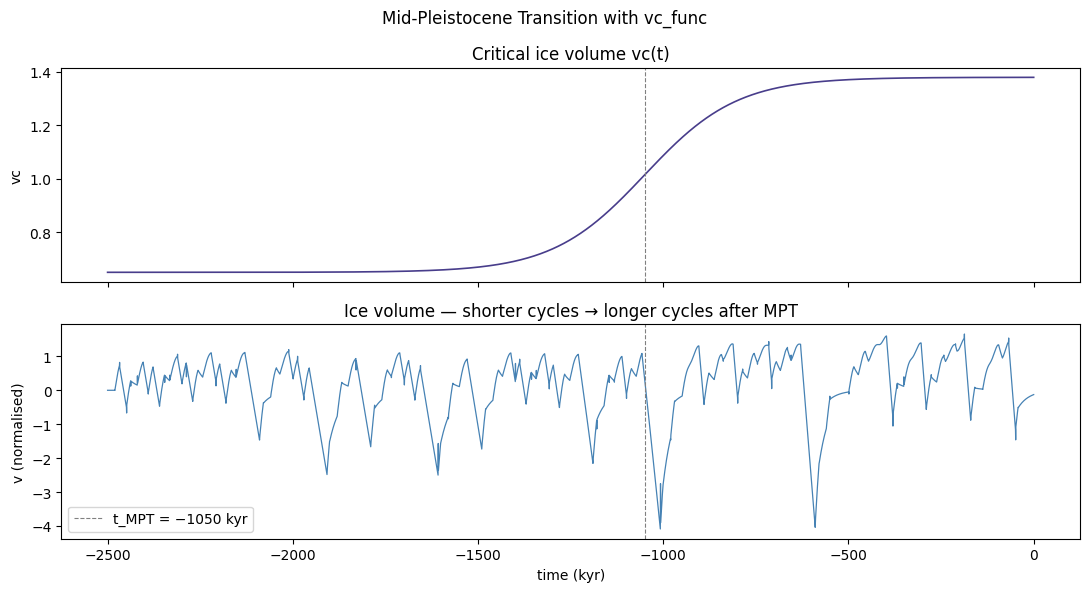

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# vc(t) on top — the evolving threshold
axes[0].plot(t_long, vc_vals, color='darkslateblue', lw=1.2)
axes[0].axvline(-1050, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('vc')
axes[0].set_title('Critical ice volume vc(t)')

# Ice volume — shorter cycles before MPT, longer after
axes[1].plot(time_mpt, v_mpt, color='steelblue', lw=0.9)
axes[1].axvline(-1050, color='gray', ls='--', lw=0.8, label='t_MPT = \u22121050 kyr')
axes[1].set_ylabel('v (normalised)'); axes[1].set_xlabel('time (kyr)')
axes[1].set_title('Ice volume — shorter cycles \u2192 longer cycles after MPT')
axes[1].legend()

for ax in axes:
    ax.invert_xaxis()
fig.suptitle('Mid-Pleistocene Transition with vc_func')
plt.tight_layout(); plt.show()

**Figure.** Top: the evolving $v_c$ threshold. Bottom: simulated ice volume over 2500 kyr. Before ~1 Ma the model produces rapid ~40 kyr cycles (low threshold, obliquity-forced). After the MPT, $v_c$ rises and the system skips forcing beats, locking into the longer ~100 kyr rhythm seen in the Pleistocene record.

## Glaciation and deglaciation thresholds: f1 and f2

**`f1`** controls when deglaciation ends and glaciation resumes: k=2 → k=1 when f < f1. More negative `f1` means insolation must drop further before glaciation can restart, extending the deglaciation phase and altering cycle asymmetry.

**`f2`** defines the upper end of the bi-stable regime. For f1 < f < f2 the equilibrium ice volume `ve` depends on whether the current `v` is above or below the unstable equilibrium `vu` — both the interglacial (`ve = 0`) and glacial (`ve = vg`) attractors exist simultaneously in this window.


In [11]:
# Compare three f1 values — all else default (vc=1.4)
f1_values = [-10, -16, -25]
f1_colors = ['steelblue', 'seagreen', 'firebrick']
f1_runs   = []

for f1_val in f1_values:
    m = Model3(f1=f1_val)
    m.register_forcing('insolation', cc.Forcing(calc_f))
    out = m.integrate(t_span=(-1000, 0), y0=[0.0, 1], method='RK45',
                      kwargs={'max_step': 0.5})
    f1_runs.append((f1_val, out))
    k_out = out.state_variables['k']
    n_t   = int(np.sum(np.diff(k_out) > 0))
    print(f"f1={f1_val:>4}: {n_t} terminations in 1000 kyr  "
          f"(mean cycle ~{1000 / max(n_t, 1):.0f} kyr)")

f1= -10: 10 terminations in 1000 kyr  (mean cycle ~100 kyr)
f1= -16: 7 terminations in 1000 kyr  (mean cycle ~143 kyr)
f1= -25: 5 terminations in 1000 kyr  (mean cycle ~200 kyr)


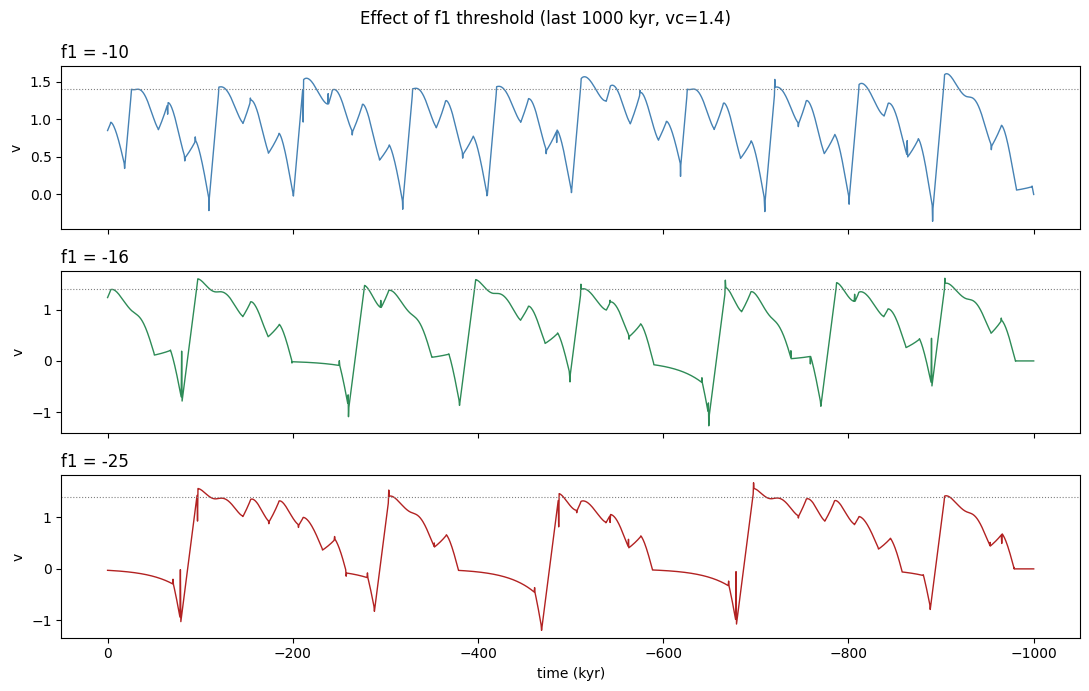

In [12]:
fig, axes = plt.subplots(len(f1_values), 1, figsize=(11, 7), sharex=True)

for ax, (f1_val, out), color in zip(axes, f1_runs, f1_colors):
    v_out = out.state_variables['v']
    ax.plot(out.time, v_out, color=color, lw=1)
    ax.axhline(1.4, color='gray', ls=':', lw=0.8)   # vc reference
    ax.set_ylabel('v')
    ax.set_title(f'f1 = {f1_val}', loc='left')
    ax.invert_xaxis()

axes[-1].set_xlabel('time (kyr)')
fig.suptitle('Effect of f1 threshold (last 1000 kyr, vc=1.4)')
plt.tight_layout(); plt.show()

**Figure.** Ice volume for three deglaciation restart thresholds $f_1$. High $f_1=-10$ (less negative): glaciation resumes at a relatively high insolation value — cycles are shorter and more frequent. Low $f_1=-25$: the system stays in the interglacial state longer, producing extended warm periods and occasional cycle skipping. $f_1=-16$ (default) gives a good balance between termination frequency and cycle length.

## Solver notes

**`max_step=0.5` kyr is required.** Regime switches (k=1↔2) are discrete events evaluated inside `dydt`. An adaptive solver with unrestricted step size can stride over a switch condition, silently missing terminations. Always pass `kwargs={'max_step': 0.5}`.

**Time is in kyr; negative = past (ka BP).** `t_span=(-2000, 0)` runs from 2000 ka to the present.

**Initial condition `y0=[v0, k0]`:** `v0=0.0` starts ice-free; `k0=1` starts in the glaciation phase. Starting with `k0=2` (deglaciation) and `v0=0` produces an immediate spurious termination.

**`k` is non-integrated.** The ODE solver only integrates `v`. The regime index `k` is updated in-place inside `dydt` and stored alongside `v` in the output's state variable array.

**Callable parameters must have signature `(t)`, `(t, state)`, or `(t, state, model)`.** The dispatcher counts all positional arguments, including those with defaults. Functions with keyword-only defaults like `vc_func(t, vc1=..., vc2=...)` must be wrapped:
```python
Model3(vc=lambda t: vc_func(t))
```
